In [429]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import plotly.express as px

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [430]:
users_df = pd.read_csv("../data/users.csv")
events_df = pd.read_csv("../data/events_base.csv")
resources_df = pd.read_csv("../data/resources.csv")
sessions_df = pd.read_csv("../data/sessions.csv")

### Merging all 4 files into a single df

In [431]:
df = sessions_df.merge(events_df, on=["session_id", 'user_id'], how = 'left')
df = df.merge(users_df, on =['user_id'], how = 'left')
df = df.merge(resources_df, on = ['resource_id'], how = 'left')

### Aggregating sessions by session_id

In [432]:
df["cross_department_access"] = (
    df["department"] != df["owner_department"]
).astype(int)

In [433]:
df["sensitive_access"] = (
    (df["sensitivity_score"] >= 0.6) & (df["sensitivity_score"] < 0.9)
).astype(int)

In [434]:
df['admin_only_access'] = (
    df['sensitivity_score'] >= 0.9
).astype(int)

In [435]:
df["admin_misuse"] = (
    (df["resource_type"] == "admin_only") &
    (df["privilege_level"] < 3)
).astype(int)

In [436]:
df["invalid_access"] = (
    df["access_success"] == False
).astype(int)

In [437]:
grouped_df = df.groupby("session_id").agg({
    "event_id": "count",
    "data_volume_mb": "sum",
    "invalid_access": "sum",
    "cross_department_access": "sum",
    "sensitive_access": "sum",
    "admin_only_access": "sum",
    "admin_misuse": "sum",
    "resource_id": "nunique",
    "sensitivity_score": "mean"
}).reset_index()

In [438]:
grouped_df = grouped_df.rename(columns={
    "event_id": "total_events",
    "data_volume_mb": "total_data_volume",
    "invalid_access": "failed_attempts",
    "cross_department_access": "cross_dept_count",
    "sensitive_access": "sensitive_resource_count",
    "admin_only_access": "admin_only_resource_count",
    "admin_misuse": "admin_misuse_count",
    "resource_id": "unique_resources",
    "sensitivity_score": "avg_sensitivity"
})

In [439]:
grouped_df = grouped_df.merge(
    sessions_df,
    on=["session_id"],
    how="left"
)

In [440]:
grouped_df = grouped_df.merge(
    users_df[[
        "user_id",
        "tenure_months",
        "role",
        "privilege_level",
        "typical_login_hour",
        "login_hour_std"
    ]],
    on="user_id",
    how="left"
)

### Adding event types and session duration

In [441]:
grouped_df["session_duration"] = (
    pd.to_datetime(grouped_df["session_end"]) -
    pd.to_datetime(grouped_df["session_start"])
).dt.total_seconds() / 60

In [442]:
event_type_counts = pd.crosstab(df["session_id"], df["event_type"])

In [443]:
for col in ["file_access", "api_call", "admin_action"]:
    if col not in event_type_counts.columns:
        event_type_counts[col] = 0

In [444]:
grouped_df = grouped_df.merge(
    event_type_counts,
    on="session_id",
    how="left"
)

### Calculating the login hour deviation

In [445]:
grouped_df["login_hour"] = pd.to_datetime(
    grouped_df["session_start"]
).dt.hour

In [446]:
grouped_df["login_zscore"] = (
    grouped_df["login_hour"] - grouped_df["typical_login_hour"]
) / grouped_df["login_hour_std"]

grouped_df["abs_login_z"] = abs(grouped_df["login_zscore"])

### Dropping redudant columns which are unique and date times

In [447]:
grouped_df = grouped_df.drop(columns=["session_start", "session_end"])

### Storing event ratios instead of raw counts

In [448]:
grouped_df["failed_ratio"] = (
    grouped_df["failed_attempts"] / grouped_df["total_events"]
)

In [449]:
print(df.columns)

Index(['session_id', 'user_id', 'session_start', 'session_end', 'device_type',
       'location', 'login_method', 'mfa_used', 'event_id', 'timestamp',
       'event_type', 'action', 'resource_id', 'data_volume_mb',
       'access_success', 'privilege_used', 'admin_command_type', 'role',
       'department', 'privilege_level', 'tenure_months', 'typical_login_hour',
       'login_hour_std', 'file_access_prob', 'api_call_prob', 'activity_level',
       'data_intensity', 'resource_type', 'owner_department',
       'sensitivity_score', 'cross_department_access', 'sensitive_access',
       'admin_only_access', 'admin_misuse', 'invalid_access'],
      dtype='object')


In [450]:
grouped_df["admin_ratio"] = (
    grouped_df["admin_action"] / grouped_df["total_events"]
)

In [451]:
grouped_df["sensitive_ratio"] = (
    grouped_df["sensitive_resource_count"] / grouped_df["total_events"]
)

In [452]:
grouped_df["admin_only_ratio"] = (
    grouped_df["admin_only_resource_count"] / grouped_df["total_events"]
)

In [453]:
grouped_df["cross_dept_ratio"] = (
    grouped_df["cross_dept_count"] / grouped_df["total_events"]
)

In [454]:
grouped_df["resource_density"] = (
    grouped_df["unique_resources"] / grouped_df["total_events"]
)

In [455]:
grouped_df["api_ratio"] = (
    grouped_df["api_call"] / grouped_df["total_events"]
)

In [456]:
grouped_df["file_ratio"] = (
    grouped_df["file_access"] / grouped_df["total_events"]
)

In [457]:
grouped_df["events_per_minute"] = (
    grouped_df["total_events"] /
    grouped_df["session_duration"]
)

In [458]:
grouped_df["avg_data_per_event"] = (
    grouped_df["total_data_volume"] / grouped_df["total_events"]
)

In [459]:
grouped_df = grouped_df.drop(columns=["cross_dept_count", "sensitive_resource_count","admin_only_resource_count", "admin_action", 'failed_attempts'])

### Dropping columns whose insights have been feature engineered

In [460]:
grouped_df = grouped_df.drop(columns=["typical_login_hour", "login_hour_std", "api_call", "file_access", "admin_misuse_count", "unique_resources","login_zscore"])

In [461]:
grouped_df.head()

,session_id,total_events,total_data_volume,avg_sensitivity,user_id,device_type,location,login_method,mfa_used,tenure_months,role,privilege_level,session_duration,login_hour,abs_login_z,failed_ratio,admin_ratio,sensitive_ratio,admin_only_ratio,cross_dept_ratio,resource_density,api_ratio,file_ratio,events_per_minute,avg_data_per_event
0,S00001,32,1515,0.324688,U000,laptop,India,password+token,True,87,admin,4,172.0,9,0.000000,0.000000,0.093750,0.125000,0.093750,0.031250,0.343750,0.468750,0.437500,0.186047,47.343750
1,S00002,22,806,0.294545,U000,vpn,India,password+token,True,87,admin,4,113.0,8,0.847458,0.090909,0.090909,0.045455,0.090909,0.181818,0.590909,0.409091,0.500000,0.194690,36.636364
2,S00003,20,1000,0.331000,U000,vpn,India,password+token,True,87,admin,4,110.0,8,0.847458,0.050000,0.050000,0.050000,0.150000,0.100000,0.550000,0.650000,0.300000,0.181818,50.000000
3,S00004,30,1315,0.269000,U000,laptop,India,password+token,True,87,admin,4,165.0,11,1.694915,0.000000,0.000000,0.066667,0.066667,0.100000,0.466667,0.566667,0.433333,0.181818,43.833333
4,S00005,28,1280,0.202143,U000,vpn,India,password+token,True,87,admin,4,148.0,9,0.000000,0.000000,0.035714,0.071429,0.000000,0.107143,0.392857,0.535714,0.428571,0.189189,45.714286


In [462]:
grouped_df.select_dtypes(include=['float64', 'int64']).corr()

,total_events,total_data_volume,avg_sensitivity,tenure_months,privilege_level,session_duration,abs_login_z,failed_ratio,admin_ratio,sensitive_ratio,admin_only_ratio,cross_dept_ratio,resource_density,api_ratio,file_ratio,events_per_minute,avg_data_per_event
total_events,1.000000,0.751837,-0.056487,0.485258,0.597876,0.906031,0.031409,-0.217147,0.390528,-0.239001,0.483693,-0.062712,-0.612103,0.446590,-0.471381,0.319665,0.556475
total_data_volume,0.751837,1.000000,-0.079454,0.323949,0.420025,0.702567,0.027869,-0.212461,0.206107,-0.205858,0.296174,-0.062262,-0.444010,0.250424,-0.262630,0.200335,0.921768
avg_sensitivity,-0.056487,-0.079454,1.000000,-0.104968,0.062819,0.047733,0.037317,0.416018,0.029555,0.911920,0.133743,0.115427,-0.174225,0.086452,-0.085192,-0.282931,-0.098814
tenure_months,0.485258,0.323949,-0.104968,1.000000,0.616183,0.392928,0.032941,-0.189568,0.577683,-0.331772,0.615141,-0.126315,-0.106855,0.421931,-0.472820,0.202547,0.187700
privilege_level,0.597876,0.420025,0.062819,0.616183,1.000000,0.541439,0.077028,-0.174334,0.618260,-0.180627,0.653485,-0.053472,-0.273224,0.652491,-0.694986,0.148075,0.271961
session_duration,0.906031,0.702567,0.047733,0.392928,0.541439,1.000000,0.065832,-0.220785,0.301085,-0.115699,0.400510,-0.020048,-0.608713,0.516595,-0.525444,-0.077423,0.545860
abs_login_z,0.031409,0.027869,0.037317,0.032941,0.077028,0.065832,1.000000,-0.016502,0.051595,0.029811,-0.004948,0.019901,-0.008523,0.097423,-0.098409,-0.061871,0.026556
failed_ratio,-0.217147,-0.212461,0.416018,-0.189568,-0.174334,-0.220785,-0.016502,1.000000,-0.125330,0.475889,-0.107622,0.056634,0.009922,-0.208493,0.212567,-0.084621,-0.207389
admin_ratio,0.390528,0.206107,0.029555,0.577683,0.618260,0.301085,0.051595,-0.125330,1.000000,-0.173724,0.552768,-0.048354,-0.120191,0.397032,-0.504982,0.183335,0.100377
sensitive_ratio,-0.239001,-0.205858,0.911920,-0.331772,-0.180627,-0.115699,0.029811,0.475889,-0.173724,1.000000,-0.221668,0.141232,-0.111498,-0.107954,0.124386,-0.324093,-0.179264


## Visualizing Trends in the data and defining normal behaviour

In [463]:
fig = px.histogram(
    grouped_df,
    x="session_duration",
    nbins=40,
    title="Session Duration Distribution",
    hover_data=["session_id", "role"]
)

fig.update_layout(bargap=0.1)
fig.show()

In [464]:
fig = px.histogram(
    grouped_df,
    x="abs_login_z",
    nbins=40,
    title="Login Deviation (Z-Score) Distribution",
    hover_data=["session_id", "role"]
)

fig.show()

In [465]:
fig = px.histogram(
    grouped_df,
    x="failed_ratio",
    nbins=40,
    title="Failed Access Ratio Distribution",
    hover_data=["session_id", "role"]
)

fig.show()

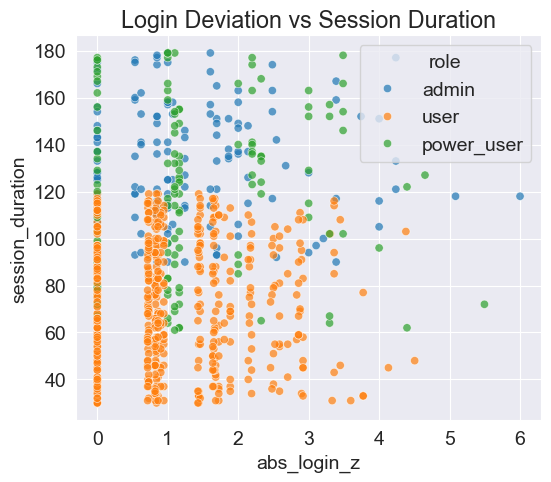

In [466]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    data=grouped_df,
    x="abs_login_z",
    y="session_duration",
    hue="role",
    alpha=0.7
)
plt.title("Login Deviation vs Session Duration")
plt.show()

In [467]:
fig = px.scatter(
    grouped_df,
    x="abs_login_z",
    y="admin_ratio",
    color="role",
    hover_data=["session_id", "total_events"],
    title="Login Deviation vs Admin Usage"
)

fig.show()

In [468]:
fig = px.scatter(
    grouped_df,
    x="session_duration",
    y="total_data_volume",
    color="role",
    hover_data=["session_id"],
    title="Session Duration vs Data Volume"
)

fig.show()

In [469]:
fig = px.scatter(
    grouped_df,
    x="events_per_minute",
    y="avg_data_per_event",
    color="role",
    hover_data=["session_id"],
    title="Activity Burstiness vs Data Intensity"
)

fig.show()

In [470]:
fig = px.box(
    grouped_df,
    x="privilege_level",
    y="total_events",
    color="privilege_level",
    hover_data=["session_id"],
    title="Activity Level by Privilege Level"
)

fig.show()

In [471]:
corr = grouped_df.corr(numeric_only=True)

fig = px.imshow(
    corr,
    text_auto=False,
    color_continuous_scale="RdBu",
    title="Feature Correlation Heatmap"
)

fig.show()

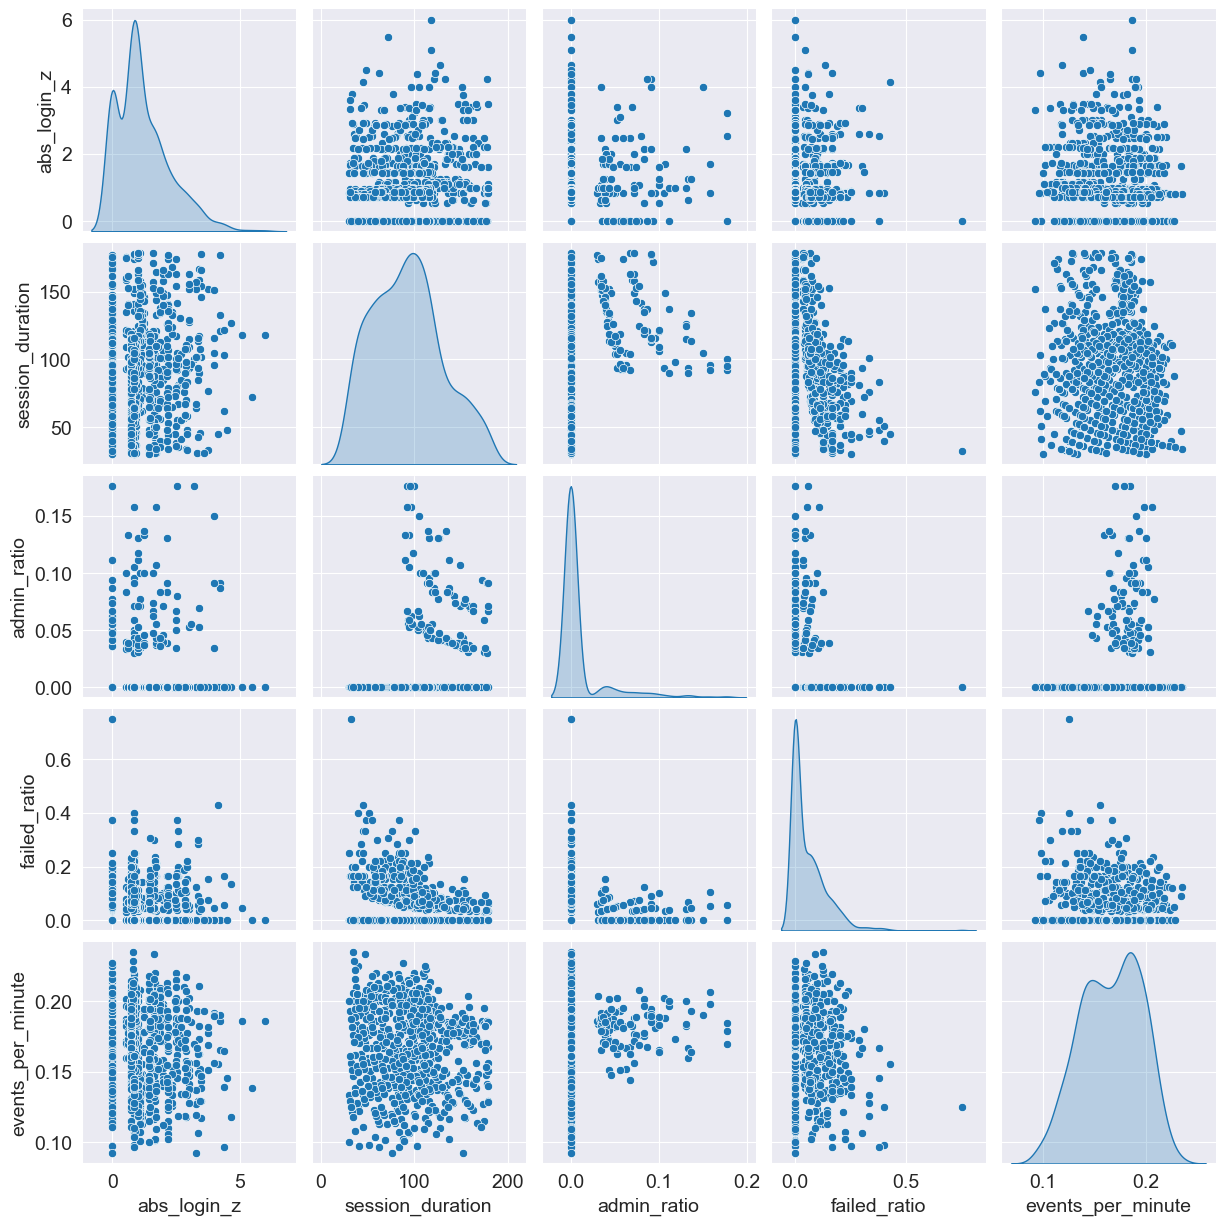

In [472]:
sns.pairplot(
    grouped_df[[
        "abs_login_z",
        "session_duration",
        "admin_ratio",
        "failed_ratio",
        "events_per_minute"
    ]],
    diag_kind="kde"
)
plt.show()

In [473]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

numeric_df = grouped_df.select_dtypes(include="number")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_df)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

grouped_df["PC1"] = X_pca[:,0]
grouped_df["PC2"] = X_pca[:,1]

fig = px.scatter(
    grouped_df,
    x="PC1",
    y="PC2",
    color="role",
    hover_data=[
        "session_id",
        "abs_login_z",
        "admin_ratio",
        "failed_ratio"
    ],
    title="PCA Projection of Sessions"
)

fig.show()